# 01 — Data Understanding: Panel jugador–temporada y dataset modelizable

Este notebook documenta la fase de **comprensión de datos** del TFM *Market Value Dynamics and Inefficiency in European Football Transfers* tras la reconstrucción completa del pipeline con FBref real y Transfermarkt/Kaggle Player Scores.

El objetivo es analizar la calidad, cobertura y coherencia del dataset integrado antes de entrar en modelización econométrica y machine learning.

La unidad de análisis del proyecto es:

```text
jugador–temporada
```

El notebook analiza tres niveles:

1. **Panel completo**: `player_season_panel.parquet`  
   Dataset integrado FBref + Transfermarkt con registros emparejados y no emparejados.

2. **Dataset modelizable**: `player_season_modeling.parquet`  
   Subconjunto filtrado para análisis econométrico y construcción de rankings.

3. **Muestra econométrica final potencial**  
   Observaciones que contienen todas las variables necesarias para el modelo OLS base.

> Nota metodológica: tras la ampliación de temporadas hasta 2024-2025, la validación del matching diferencia entre cruces fuertes por club y cruces aceptados por nombre + edad + temporada. Esta distinción se incorpora explícitamente al análisis de calidad mediante `matching_method`, `matching_confidence`, `age_diff` y `club_score`.

## 1. Imports y configuración

In [94]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT = Path("..").resolve()
DATA_PROCESSED = ROOT / "data" / "processed"
REPORTS_FIGURES = ROOT / "reports" / "figures"
REPORTS_TABLES = ROOT / "reports" / "tables"

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS_TABLES.mkdir(parents=True, exist_ok=True)

PANEL_PATH = DATA_PROCESSED / "player_season_panel.parquet"
MODELING_PATH = DATA_PROCESSED / "player_season_modeling.parquet"

print("Project root:", ROOT)
print("Panel path exists:", PANEL_PATH.exists())
print("Modeling path exists:", MODELING_PATH.exists())

Project root: C:\Users\manue\Projects\market-value-football-tfm
Panel path exists: True
Modeling path exists: True


## 2. Carga de datasets

Se cargan los dos artefactos principales del pipeline:

- `player_season_panel.parquet`: panel completo tras matching FBref–Transfermarkt.
- `player_season_modeling.parquet`: dataset filtrado para modelización.

In [95]:
panel_df = pd.read_parquet(PANEL_PATH)
modeling_df = pd.read_parquet(MODELING_PATH)

print("Panel shape:", panel_df.shape)
print("Modeling shape:", modeling_df.shape)

panel_df.head()

Panel shape: (23580, 52)
Modeling shape: (3297, 54)


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status
0,Suleiman Abdullahi,Union Berlin,Bundesliga,2019-2020,2019,MF,MID,22.0000,6,1,157,1.7000,1,0,1,1,0,0,1,0,0.5700,0.0000,0.5700,0.5700,0.5700,suleiman abdullahi,"356,118.0000",Suleiman Abdullahi,"2,019.0000",2019-12-17,"1,800,000.0000",14.4033,"2,000,000.0000","1,400,000.0000",-0.2222,-0.2513,23.0171,1996-12-10 00:00:00,Nigeria,Attack,Centre-Forward,right,185.0000,1. Fußballclub Union Berlin,89.0000,L1,transfermarkt_kaggle_player_scores,exact_age_validated,0.8500,1.0171,66.6667,True
1,David Abraham,Eintracht Frankfurt,Bundesliga,2019-2020,2019,DF,DEF,33.0000,20,19,1688,18.8000,2,0,2,2,0,0,2,1,0.1100,0.0000,0.1100,0.1100,0.1100,david abraham,"58,178.0000",David Abraham,"2,019.0000",2019-12-17,"1,500,000.0000",14.2210,"2,500,000.0000","1,200,000.0000",-0.2000,-0.2231,33.4237,1986-07-15 00:00:00,Argentina,Defender,Centre-Back,right,188.0000,Eintracht Frankfurt Fußball AG,24.0000,L1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.4237,77.5510,True
2,Amir Abrashi,Freiburg,Bundesliga,2019-2020,2019,MF,MID,29.0000,13,8,663,7.4000,0,0,0,0,0,0,3,0,0.0000,0.0000,0.0000,0.0000,0.0000,amir abrashi,"66,005.0000",Amir Abrashi,"2,019.0000",2019-12-17,"2,000,000.0000",14.5087,"2,500,000.0000","1,600,000.0000",-0.2000,-0.2231,29.7248,1990-03-27 00:00:00,Albania,Midfield,Defensive Midfield,right,172.0000,Grasshopper Club Zürich,504.0000,C1,transfermarkt_kaggle_player_scores,exact_age_validated,0.8500,0.7248,25.8065,True
3,Tyler Adams,RB Leipzig,Bundesliga,2019-2020,2019,"MF,DF",DEF,20.0000,14,10,953,10.6000,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,tyler adams,"332,705.0000",Tyler Adams,"2,019.0000",2019-12-17,"13,000,000.0000",16.3805,"13,000,000.0000","11,500,000.0000",-0.1154,-0.1226,20.8378,1999-02-14 00:00:00,United States,Midfield,Defensive Midfield,right,175.0000,Association Football Club Bournemouth,989.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_validated,0.8500,0.8378,21.2766,True
4,Sargis Adamyan,Hoffenheim,Bundesliga,2019-2020,2019,"MF,FW",MID,26.0000,15,6,746,8.3000,5,1,6,5,0,0,1,0,0.6000,0.1200,0.7200,0.6000,0.7200,sargis adamyan,"125,614.0000",Sargis Adamyan,"2,019.0000",2019-12-17,"4,000,000.0000",15.2018,"3,000,000.0000","5,000,000.0000",0.2500,0.2231,26.5681,1993-05-23 00:00:00,Armenia,Attack,Centre-Forward,right,184.0000,1. Fußball-Club Köln,3.0000,L1,transfermarkt_kaggle_player_scores,exact_age_validated,0.8500,0.5681,14.8148,True


## 3. Resumen ejecutivo de cobertura

Este bloque resume las dimensiones principales del dataset reconstruido. Es una celda clave para documentar el estado actual del proyecto en la memoria.

In [96]:
summary = pd.DataFrame({
    "dataset": ["player_season_panel", "player_season_modeling"],
    "rows": [len(panel_df), len(modeling_df)],
    "columns": [panel_df.shape[1], modeling_df.shape[1]],
    "players": [
        panel_df["player_name_fbref"].nunique() if "player_name_fbref" in panel_df.columns else np.nan,
        modeling_df["player_name_fbref"].nunique() if "player_name_fbref" in modeling_df.columns else np.nan,
    ],
    "seasons": [
        panel_df["season"].nunique() if "season" in panel_df.columns else np.nan,
        modeling_df["season"].nunique() if "season" in modeling_df.columns else np.nan,
    ],
    "leagues": [
        panel_df["league"].nunique() if "league" in panel_df.columns else np.nan,
        modeling_df["league"].nunique() if "league" in modeling_df.columns else np.nan,
    ],
})

summary

,dataset,rows,columns,players,seasons,leagues
0,player_season_panel,23580,52,8587,6,7
1,player_season_modeling,3297,54,1847,6,7


## 4. Estructura y tipos de datos

Se inspeccionan las columnas disponibles y sus tipos. Este paso ayuda a verificar si el pipeline ha dejado las variables en formato adecuado para el análisis posterior.

In [97]:
panel_info = pd.DataFrame({
    "column": panel_df.columns,
    "dtype": panel_df.dtypes.astype(str).values,
    "missing": panel_df.isna().sum().values,
    "missing_pct": (panel_df.isna().mean() * 100).round(2).values,
})

panel_info.sort_values("missing_pct", ascending=False).head(30)

,column,dtype,missing,missing_pct
32,market_value_prev_eur,float64,3742,15.8700
43,current_club_name_tm,str,3000,12.7200
45,competition_id_tm,str,3000,12.7200
38,nationality,str,2898,12.2900
41,foot,str,2832,12.0100
42,height_in_cm,float64,2822,11.9700
34,market_value_growth_1y,float64,2814,11.9300
35,delta_log_market_value_1y,float64,2814,11.9300
33,market_value_next_eur,float64,2814,11.9300
40,sub_position_tm,str,2749,11.6600


In [98]:
modeling_info = pd.DataFrame({
    "column": modeling_df.columns,
    "dtype": modeling_df.dtypes.astype(str).values,
    "missing": modeling_df.isna().sum().values,
    "missing_pct": (modeling_df.isna().mean() * 100).round(2).values,
})

modeling_info.sort_values("missing_pct", ascending=False).head(30)

,column,dtype,missing,missing_pct
32,market_value_prev_eur,float64,87,2.6400
45,competition_id_tm,str,10,0.3000
43,current_club_name_tm,str,10,0.3000
38,nationality,str,5,0.1500
42,height_in_cm,float64,2,0.0600
41,foot,str,2,0.0600
6,position_group,str,0,0.0000
7,age_fbref,float64,0,0.0000
8,matches_played,int64,0,0.0000
9,starts,int64,0,0.0000


# 5. Análisis del panel completo

El panel completo permite analizar la cobertura real de FBref y la calidad del matching con Transfermarkt. Esta sección no debe confundirse con el dataset final de modelización: incluye tanto observaciones emparejadas como no emparejadas.

## 5.1 Cobertura por temporada y liga

In [99]:
panel_season_counts = panel_df["season"].value_counts().sort_index()
panel_league_counts = panel_df["league"].value_counts()

print("Rows by season:")
print(panel_season_counts)

print("\nRows by league:")
print(panel_league_counts)

Rows by season:
season
2019-2020    3778
2020-2021    3887
2021-2022    4036
2022-2023    3995
2023-2024    3912
2024-2025    3972
Name: count, dtype: int64

Rows by league:
league
Serie A           3704
LaLiga            3575
Ligue 1           3429
Liga Portugal     3386
Premier League    3323
Eredivisie        3123
Bundesliga        3040
Name: count, dtype: int64


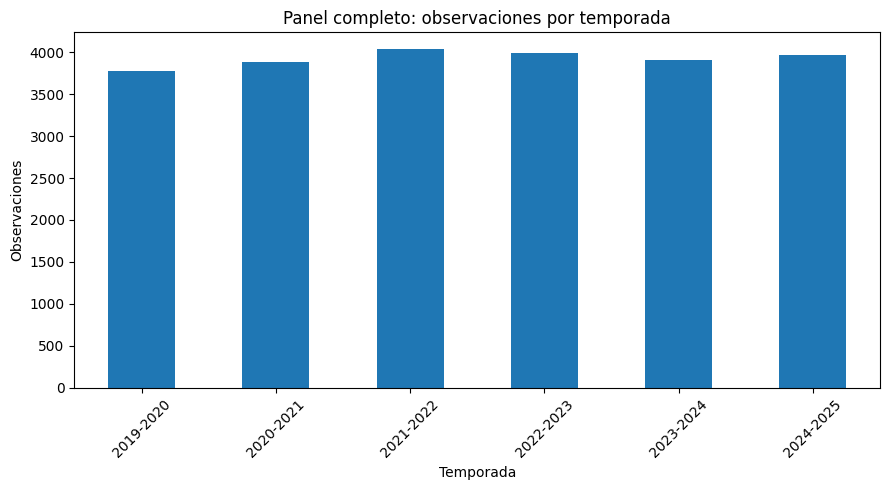

In [100]:
fig, ax = plt.subplots(figsize=(9, 5))
panel_season_counts.plot(kind="bar", ax=ax)
ax.set_title("Panel completo: observaciones por temporada")
ax.set_xlabel("Temporada")
ax.set_ylabel("Observaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

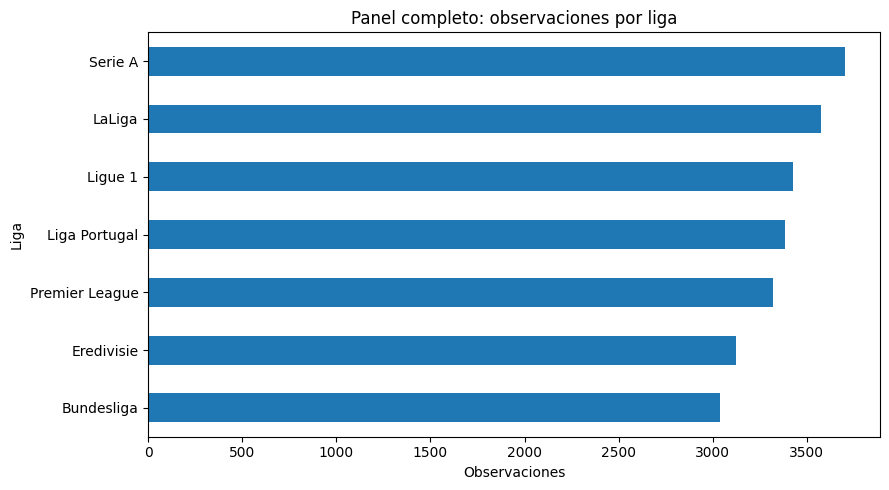

In [101]:
fig, ax = plt.subplots(figsize=(9, 5))
panel_league_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Panel completo: observaciones por liga")
ax.set_xlabel("Observaciones")
ax.set_ylabel("Liga")
plt.tight_layout()
plt.show()

## 5.2 Calidad del matching FBref–Transfermarkt

El matching es la pieza crítica del pipeline, dado que FBref y Transfermarkt no comparten un identificador común. Se evalúa mediante:

- `matching_status`: indica si existe cruce con Transfermarkt.
- `matching_method`: método de validación usado.
- `matching_confidence`: confianza asignada al cruce.
- `age_diff`: diferencia de edad entre fuentes.
- `club_score`: similitud entre clubes.

Interpretación operativa:

```text
exact_age_club_validated  → match fuerte: nombre + temporada + edad + club
exact_age_validated       → match medio: nombre + temporada + edad
fuzzy_age_club_validated  → match fuzzy validado por edad y club
NaN                       → no emparejado
```

In [102]:
match_rate = panel_df["matching_status"].mean()
print(f"Global match rate: {match_rate:.2%}")

panel_df["matching_method"].value_counts(dropna=False)

Global match rate: 88.36%


matching_method
exact_age_validated         18669
NaN                          2744
exact_age_club_validated     2146
fuzzy_age_club_validated       21
Name: count, dtype: int64

In [103]:
match_by_season = (
    panel_df
    .groupby("season")["matching_status"]
    .agg(["count", "sum", "mean"])
    .sort_index()
)

match_by_season

,count,sum,mean
season,,,
2019-2020,3778,3352,0.8872
2020-2021,3887,3491,0.8981
2021-2022,4036,3595,0.8907
2022-2023,3995,3591,0.8989
2023-2024,3912,3519,0.8995
2024-2025,3972,3288,0.8278


In [104]:
match_by_league = (
    panel_df
    .groupby("league")["matching_status"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

match_by_league

,count,sum,mean
league,,,
Bundesliga,3040,2834,0.9322
Premier League,3323,3083,0.9278
Serie A,3704,3402,0.9185
Ligue 1,3429,3111,0.9073
Eredivisie,3123,2832,0.9068
LaLiga,3575,3029,0.8473
Liga Portugal,3386,2545,0.7516


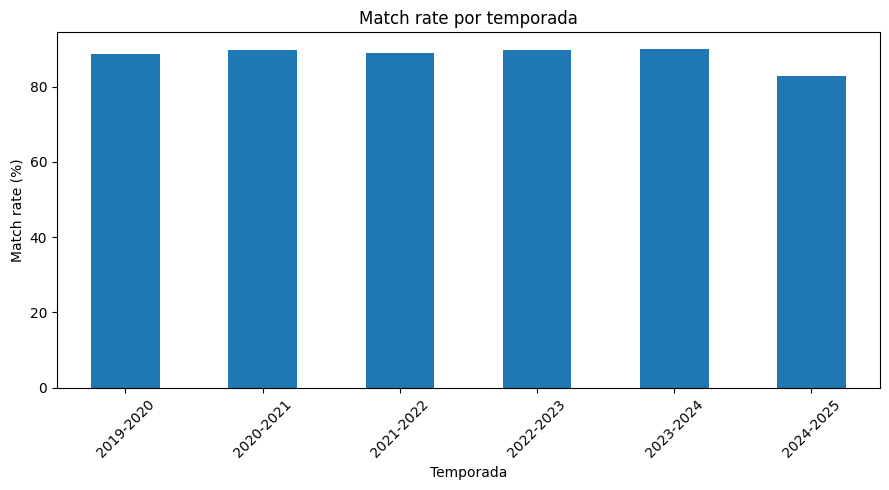

In [105]:
fig, ax = plt.subplots(figsize=(9, 5))
(match_by_season["mean"] * 100).plot(kind="bar", ax=ax)
ax.set_title("Match rate por temporada")
ax.set_xlabel("Temporada")
ax.set_ylabel("Match rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

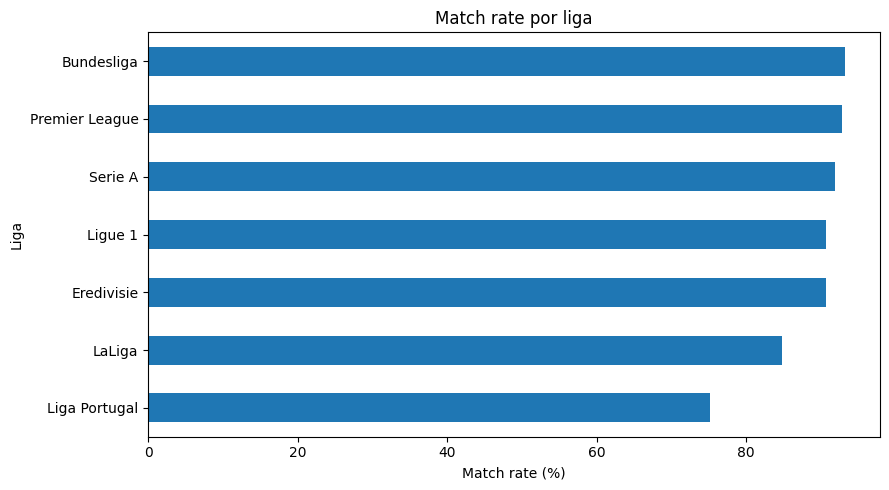

In [106]:
fig, ax = plt.subplots(figsize=(9, 5))
(match_by_league["mean"].sort_values() * 100).plot(kind="barh", ax=ax)
ax.set_title("Match rate por liga")
ax.set_xlabel("Match rate (%)")
ax.set_ylabel("Liga")
plt.tight_layout()
plt.show()

## 5.3 Distribución de confianza del matching

Se analiza si la muestra depende excesivamente de matches de confianza media. Este punto es importante porque los registros `exact_age_validated` se aceptan sin validación fuerte de club y deben tratarse con cautela en la interpretación.

In [107]:
matching_quality_cols = [
    col for col in ["matching_confidence", "age_diff", "club_score"]
    if col in panel_df.columns
]

panel_df.loc[panel_df["matching_status"], matching_quality_cols].describe()

,matching_confidence,age_diff,club_score
count,"20,836.0000","20,833.0000","20,836.0000"
mean,0.8656,0.7576,37.3033
std,0.0457,0.3095,22.9466
min,0.8500,0.0014,0.0000
25%,0.8500,0.5222,21.0526
50%,0.8500,0.7474,29.4118
75%,0.8500,0.9877,50.0000
max,1.0000,1.4997,100.0000


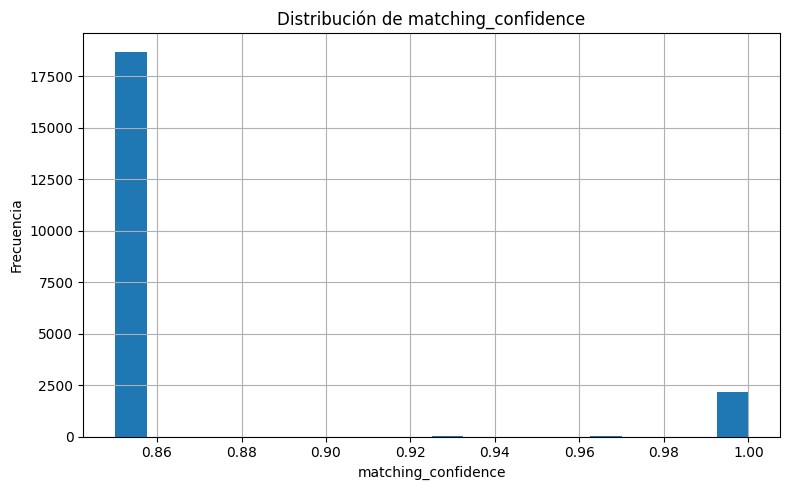

In [108]:
if "matching_confidence" in panel_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    panel_df.loc[panel_df["matching_status"], "matching_confidence"].hist(bins=20, ax=ax)
    ax.set_title("Distribución de matching_confidence")
    ax.set_xlabel("matching_confidence")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

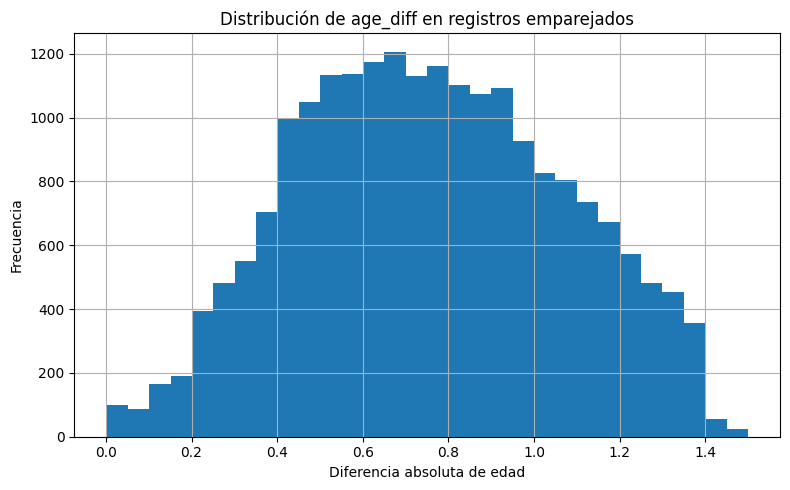

In [109]:
if "age_diff" in panel_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    panel_df.loc[panel_df["matching_status"], "age_diff"].hist(bins=30, ax=ax)
    ax.set_title("Distribución de age_diff en registros emparejados")
    ax.set_xlabel("Diferencia absoluta de edad")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# 6. Análisis del dataset modelizable

El dataset modelizable es el subconjunto que supera filtros de calidad, edad, minutos y disponibilidad del target. Es el dataset que alimenta los notebooks de modelización.

## 6.1 Cobertura final por temporada, liga y posición

In [110]:
print("Modeling shape:", modeling_df.shape)

print("\nRows by season:")
print(modeling_df["season"].value_counts().sort_index())

print("\nRows by league:")
print(modeling_df["league"].value_counts())

print("\nRows by position_group:")
print(modeling_df["position_group"].value_counts())

Modeling shape: (3297, 54)

Rows by season:
season
2019-2020    537
2020-2021    536
2021-2022    544
2022-2023    542
2023-2024    586
2024-2025    552
Name: count, dtype: int64

Rows by league:
league
Ligue 1           627
Eredivisie        557
Serie A           494
Premier League    466
Bundesliga        438
LaLiga            373
Liga Portugal     342
Name: count, dtype: int64

Rows by position_group:
position_group
MID    1705
DEF    1147
ATT     351
GK       94
Name: count, dtype: int64


In [111]:
modeling_coverage = (
    modeling_df
    .groupby("season")
    .agg(
        n_obs=("player_name_fbref", "count"),
        n_players=("player_name_fbref", "nunique"),
        mean_age=("age", "mean"),
        median_market_value=("market_value_eur", "median"),
        mean_minutes=("minutes_played", "mean"),
    )
    .reset_index()
)

modeling_coverage

,season,n_obs,n_players,mean_age,median_market_value,mean_minutes
0,2019-2020,537,526,21.4298,"6,000,000.0000","1,426.0354"
1,2020-2021,536,531,21.2552,"4,500,000.0000","1,501.8526"
2,2021-2022,544,533,21.2962,"5,000,000.0000","1,451.3585"
3,2022-2023,542,527,21.3355,"5,000,000.0000","1,461.1107"
4,2023-2024,586,577,21.3379,"5,000,000.0000","1,434.7270"
5,2024-2025,552,541,21.3202,"6,000,000.0000","1,429.3116"


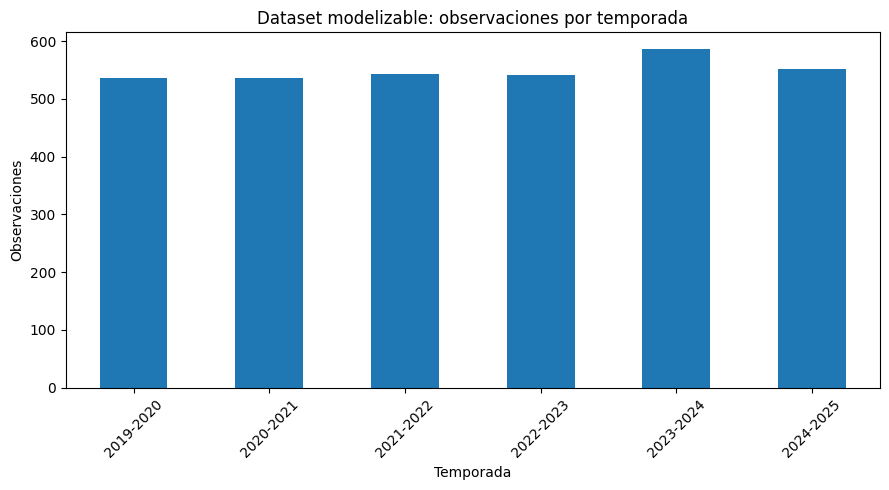

In [112]:
fig, ax = plt.subplots(figsize=(9, 5))
modeling_df["season"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Dataset modelizable: observaciones por temporada")
ax.set_xlabel("Temporada")
ax.set_ylabel("Observaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

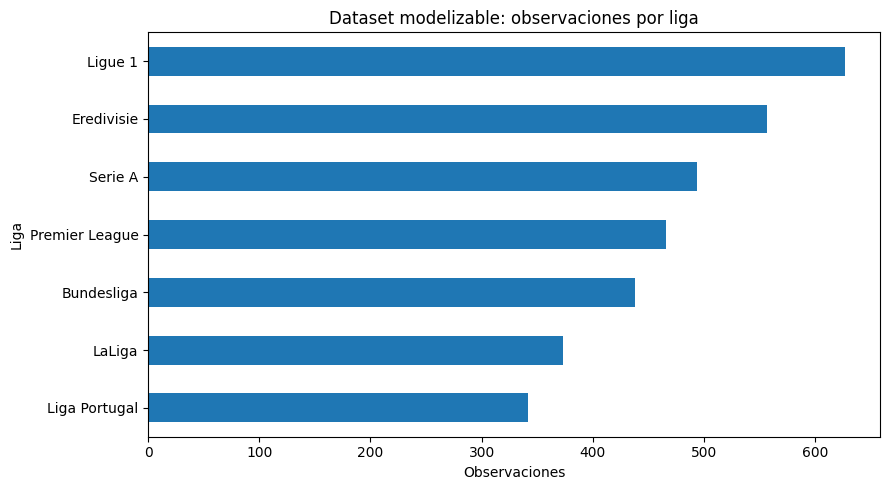

In [113]:
fig, ax = plt.subplots(figsize=(9, 5))
modeling_df["league"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("Dataset modelizable: observaciones por liga")
ax.set_xlabel("Observaciones")
ax.set_ylabel("Liga")
plt.tight_layout()
plt.show()

## 6.2 Distribución de variables demográficas y de exposición competitiva

In [114]:
modeling_df[["age", "minutes_played"]].describe()

,age,minutes_played
count,"3,297.0000","3,297.0000"
mean,21.3292,"1,450.3988"
std,1.2212,779.0758
min,18.0068,300.0000
25%,20.4928,766.0000
50%,21.5633,"1,356.0000"
75%,22.3710,"2,050.0000"
max,22.9979,"3,420.0000"


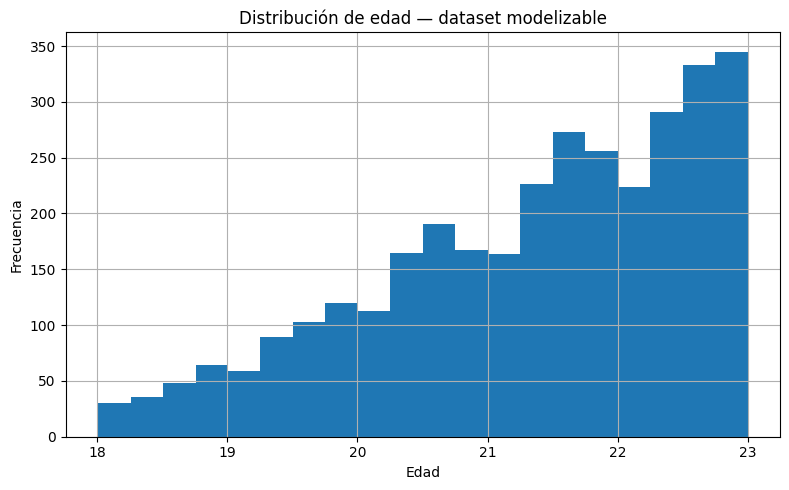

In [115]:
fig, ax = plt.subplots(figsize=(8, 5))
modeling_df["age"].hist(bins=20, ax=ax)
ax.set_title("Distribución de edad — dataset modelizable")
ax.set_xlabel("Edad")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

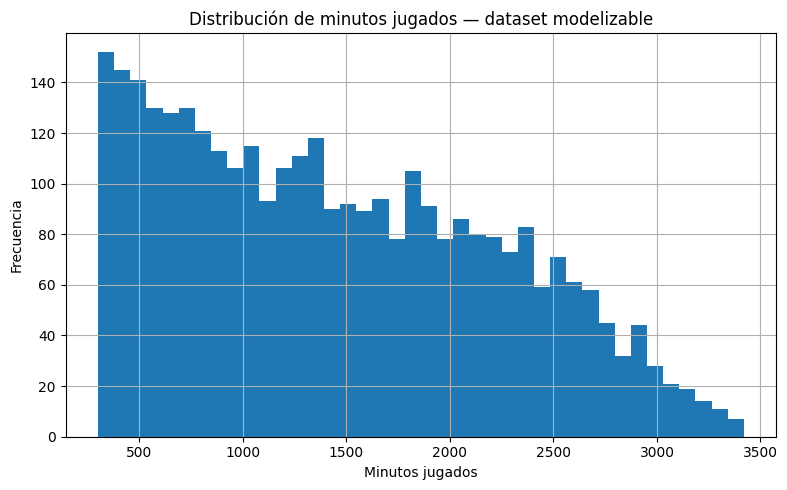

In [116]:
fig, ax = plt.subplots(figsize=(8, 5))
modeling_df["minutes_played"].hist(bins=40, ax=ax)
ax.set_title("Distribución de minutos jugados — dataset modelizable")
ax.set_xlabel("Minutos jugados")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 6.3 Análisis del target: valor de mercado

Se analiza `market_value_eur` y su transformación logarítmica `log_market_value_eur`. La transformación logarítmica es necesaria por la fuerte asimetría del valor de mercado en fútbol profesional.

In [117]:
modeling_df[["market_value_eur", "log_market_value_eur"]].describe()

,market_value_eur,log_market_value_eur
count,"3,297.0000","3,297.0000"
mean,"11,559,152.2596",15.4508
std,"17,547,390.0485",1.3134
min,"500,000.0000",13.1224
25%,"2,000,000.0000",14.5087
50%,"5,000,000.0000",15.4249
75%,"14,000,000.0000",16.4546
max,"200,000,000.0000",19.1138


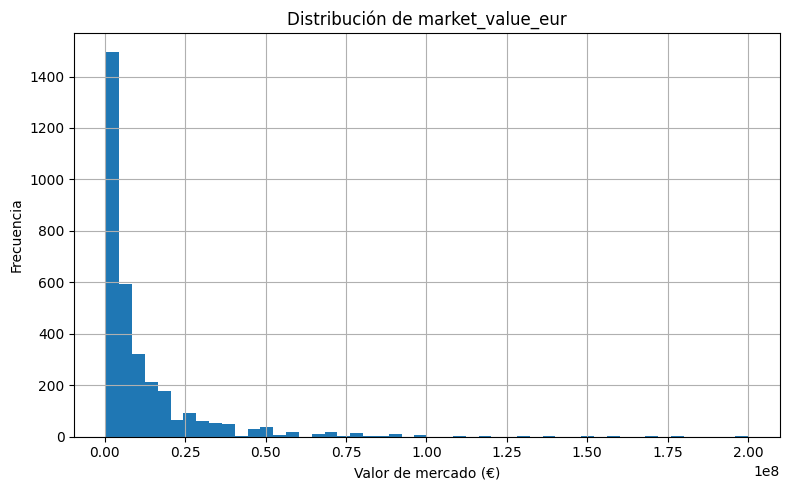

In [118]:
fig, ax = plt.subplots(figsize=(8, 5))
modeling_df["market_value_eur"].hist(bins=50, ax=ax)
ax.set_title("Distribución de market_value_eur")
ax.set_xlabel("Valor de mercado (€)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

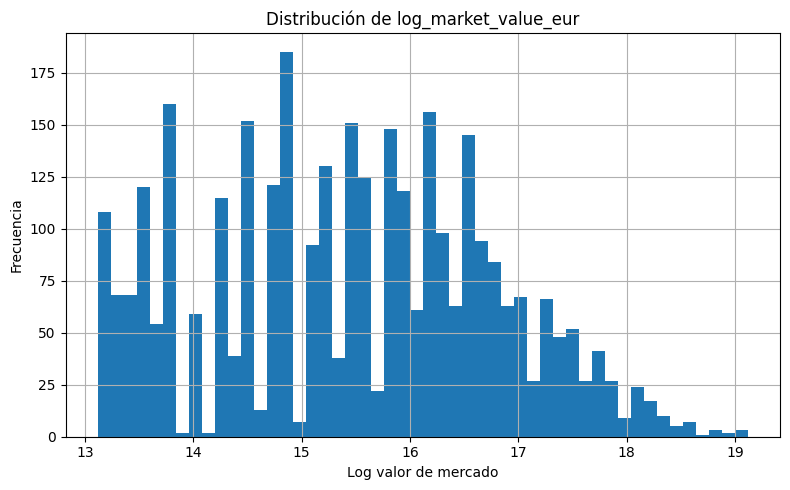

In [119]:
fig, ax = plt.subplots(figsize=(8, 5))
modeling_df["log_market_value_eur"].hist(bins=50, ax=ax)
ax.set_title("Distribución de log_market_value_eur")
ax.set_xlabel("Log valor de mercado")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [120]:
market_by_league = (
    modeling_df
    .groupby("league")
    .agg(
        n_obs=("player_name_fbref", "count"),
        median_market_value=("market_value_eur", "median"),
        mean_market_value=("market_value_eur", "mean"),
        median_log_market_value=("log_market_value_eur", "median"),
    )
    .sort_values("median_market_value", ascending=False)
)

market_by_league

,n_obs,median_market_value,mean_market_value,median_log_market_value
league,,,,
Premier League,466,"18,000,000.0000","23,263,197.4249",16.7059
LaLiga,373,"7,500,000.0000","15,980,697.0509",15.8304
Bundesliga,438,"7,500,000.0000","14,863,013.6986",15.8304
Serie A,494,"6,000,000.0000","10,387,753.0364",15.6073
Ligue 1,627,"5,000,000.0000","9,639,234.4498",15.4249
Liga Portugal,342,"2,000,000.0000","4,329,605.2632",14.5087
Eredivisie,557,"1,300,000.0000","3,847,396.7684",14.0779


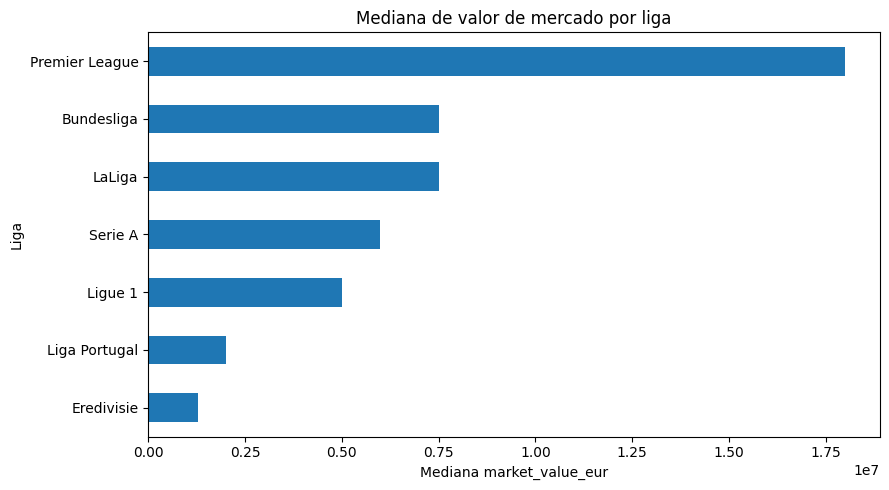

In [121]:
fig, ax = plt.subplots(figsize=(9, 5))
market_by_league["median_market_value"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Mediana de valor de mercado por liga")
ax.set_xlabel("Mediana market_value_eur")
ax.set_ylabel("Liga")
plt.tight_layout()
plt.show()

## 6.4 Variables deportivas principales

Se revisan las variables deportivas que alimentan el modelo econométrico interpretable inicial:

- `minutes_played`
- `goals_per90`
- `assists_per90`
- `age`

In [122]:
performance_cols = [
    col for col in [
        "minutes_played",
        "goals_per90",
        "assists_per90",
        "matches_played",
        "starts",
        "goals",
        "assists",
    ]
    if col in modeling_df.columns
]

modeling_df[performance_cols].describe()

,minutes_played,goals_per90,assists_per90,matches_played,starts,goals,assists
count,"3,297.0000","3,297.0000","3,297.0000","3,297.0000","3,297.0000","3,297.0000","3,297.0000"
mean,"1,450.3988",0.1369,0.0961,22.7088,16.1253,2.2126,1.5978
std,779.0758,0.1827,0.1153,8.4220,9.3455,3.3177,2.1011
min,300.0000,0.0000,0.0000,4.0000,0.0000,0.0000,0.0000
25%,766.0000,0.0000,0.0000,16.0000,8.0000,0.0000,0.0000
50%,"1,356.0000",0.0700,0.0600,24.0000,15.0000,1.0000,1.0000
75%,"2,050.0000",0.2100,0.1500,30.0000,24.0000,3.0000,2.0000
max,"3,420.0000",1.9000,0.9400,38.0000,38.0000,36.0000,17.0000


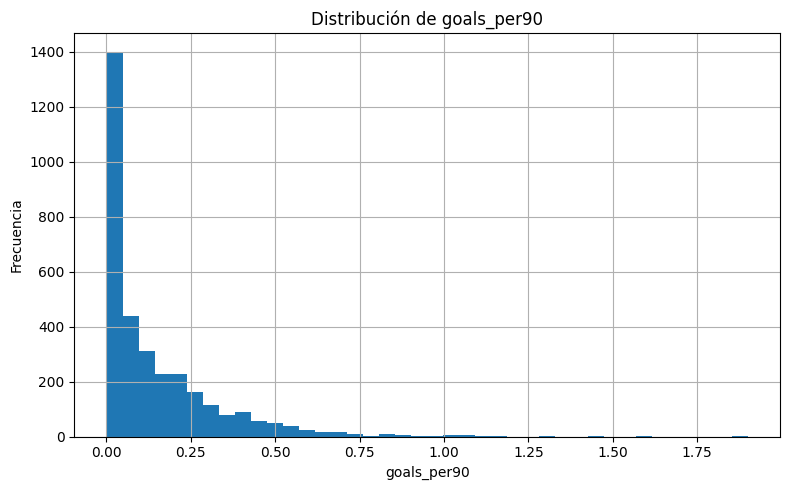

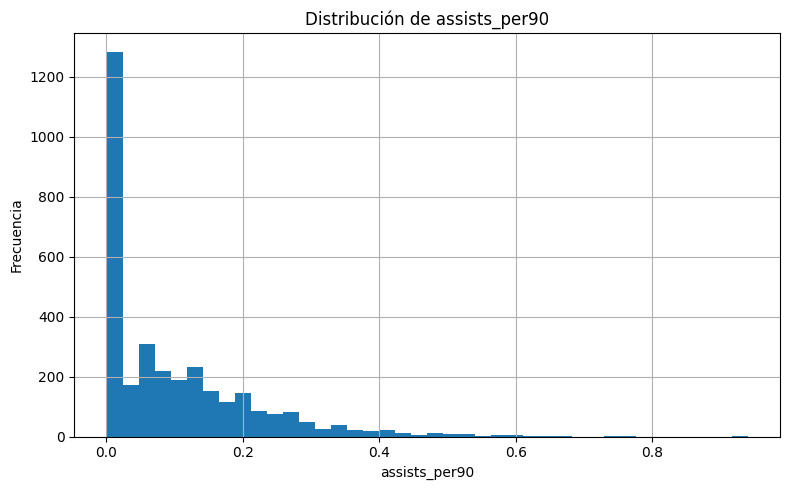

In [123]:
for col in ["goals_per90", "assists_per90"]:
    if col in modeling_df.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        modeling_df[col].dropna().hist(bins=40, ax=ax)
        ax.set_title(f"Distribución de {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

## 6.5 Missing values en dataset modelizable

In [124]:
missing_modeling = (
    modeling_df
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_modeling.columns = ["column", "missing_pct"]
missing_modeling.head(30)

,column,missing_pct
0,market_value_prev_eur,2.6388
1,competition_id_tm,0.3033
2,current_club_name_tm,0.3033
3,nationality,0.1517
4,height_in_cm,0.0607
5,foot,0.0607
6,position_group,0.0000
7,age_fbref,0.0000
8,matches_played,0.0000
9,starts,0.0000


# 7. Muestra econométrica final potencial

Esta sección replica la selección mínima necesaria para el modelo OLS interpretable con fixed effects:

Variable dependiente:

```text
log_market_value_eur
```

Variables explicativas base:

```text
minutes_played, goals_per90, assists_per90, age
```

Fixed effects:

```text
league, season, position_group
```

In [125]:
BASE_FEATURES = [
    "minutes_played",
    "goals_per90",
    "assists_per90",
    "age",
]

CATEGORICAL_FEATURES = [
    "league",
    "season",
    "position_group",
]

TARGET = "log_market_value_eur"

required_cols = BASE_FEATURES + CATEGORICAL_FEATURES + [TARGET]

eda_model_sample = modeling_df.dropna(subset=required_cols).copy()

print("Modeling dataset rows:", len(modeling_df))
print("Econometric sample rows:", len(eda_model_sample))
print("Players:", eda_model_sample["player_name_fbref"].nunique())
print("Seasons:", eda_model_sample["season"].min(), "-", eda_model_sample["season"].max())

eda_model_sample[required_cols].head()

Modeling dataset rows: 3297
Econometric sample rows: 3297
Players: 1847
Seasons: 2019-2020 - 2024-2025


,minutes_played,goals_per90,assists_per90,age,league,season,position_group,log_market_value_eur
0,2651,0.1400,0.0700,21.2731,Eredivisie,2022-2023,MID,13.9978
1,2469,0.0400,0.0000,21.6372,Premier League,2023-2024,DEF,15.7614
2,2307,0.0800,0.0400,21.2293,Eredivisie,2022-2023,DEF,13.4588
3,2106,0.2100,0.0900,22.3655,Eredivisie,2023-2024,MID,15.3196
4,2059,0.4400,0.2200,20.9090,Eredivisie,2024-2025,MID,14.2210


In [126]:
print("Econometric sample by season:")
print(eda_model_sample["season"].value_counts().sort_index())

print("\nEconometric sample by league:")
print(eda_model_sample["league"].value_counts())

print("\nEconometric sample by position:")
print(eda_model_sample["position_group"].value_counts())

Econometric sample by season:
season
2019-2020    537
2020-2021    536
2021-2022    544
2022-2023    542
2023-2024    586
2024-2025    552
Name: count, dtype: int64

Econometric sample by league:
league
Ligue 1           627
Eredivisie        557
Serie A           494
Premier League    466
Bundesliga        438
LaLiga            373
Liga Portugal     342
Name: count, dtype: int64

Econometric sample by position:
position_group
MID    1705
DEF    1147
ATT     351
GK       94
Name: count, dtype: int64


In [127]:
print("Matching method in econometric sample:")
print(eda_model_sample["matching_method"].value_counts(dropna=False))

print("\nMatching confidence summary:")
print(eda_model_sample["matching_confidence"].describe())

Matching method in econometric sample:
matching_method
exact_age_validated         3104
exact_age_club_validated     189
fuzzy_age_club_validated       4
Name: count, dtype: int64

Matching confidence summary:
count   3,297.0000
mean        0.8587
std         0.0350
min         0.8500
25%         0.8500
50%         0.8500
75%         0.8500
max         1.0000
Name: matching_confidence, dtype: float64


## 7.1 Separación temporal recomendada

Para evitar contaminación temporal, la temporada 2024-2025 puede tratarse como escenario de scoring/aplicación reciente, no necesariamente como entrenamiento principal.

Propuesta metodológica:

```text
Train: 2019-2020 a 2022-2023
Validation/Test temporal: 2023-2024
Scoring reciente: 2024-2025
```

Esta separación permite mantener una lógica realista: entrenar con pasado, validar en una temporada posterior y aplicar sobre una temporada reciente.

In [128]:
train_seasons = ["2019-2020", "2020-2021", "2021-2022", "2022-2023"]
test_season = "2023-2024"
scoring_season = "2024-2025"

train_df = eda_model_sample[eda_model_sample["season"].isin(train_seasons)].copy()
test_df = eda_model_sample[eda_model_sample["season"] == test_season].copy()
scoring_df = eda_model_sample[eda_model_sample["season"] == scoring_season].copy()

temporal_split_summary = pd.DataFrame({
    "split": ["train", "test_temporal", "scoring_recent"],
    "rows": [len(train_df), len(test_df), len(scoring_df)],
    "players": [
        train_df["player_name_fbref"].nunique(),
        test_df["player_name_fbref"].nunique(),
        scoring_df["player_name_fbref"].nunique(),
    ],
    "seasons": [
        ", ".join(train_seasons),
        test_season,
        scoring_season,
    ]
})

temporal_split_summary

,split,rows,players,seasons
0,train,2159,1289,"2019-2020, 2020-2021, 2021-2022, 2022-2023"
1,test_temporal,586,577,2023-2024
2,scoring_recent,552,541,2024-2025


# 8. Exportación de tablas de diagnóstico

Se guardan tablas relevantes para documentación y memoria.

In [129]:
summary.to_csv(REPORTS_TABLES / "01_dataset_summary.csv", index=False)
match_by_season.to_csv(REPORTS_TABLES / "01_match_rate_by_season.csv")
match_by_league.to_csv(REPORTS_TABLES / "01_match_rate_by_league.csv")
modeling_coverage.to_csv(REPORTS_TABLES / "01_modeling_coverage_by_season.csv", index=False)
market_by_league.to_csv(REPORTS_TABLES / "01_market_value_by_league.csv")
temporal_split_summary.to_csv(REPORTS_TABLES / "01_temporal_split_summary.csv", index=False)

print("Tables exported to:", REPORTS_TABLES)

Tables exported to: C:\Users\manue\Projects\market-value-football-tfm\reports\tables


# 9. Conclusiones del Data Understanding

La reconstrucción del pipeline con HTML reales de FBref y Transfermarkt/Kaggle Player Scores permite ampliar sustancialmente la cobertura temporal y muestral del proyecto.

Principales conclusiones:

1. El panel completo alcanza una cobertura de varias temporadas y ligas europeas principales, manteniendo la unidad de análisis jugador–temporada.
2. El matching FBref–Transfermarkt mejora de forma sustancial tras introducir una estrategia de validación basada en nombre normalizado, temporada, edad y método de confianza.
3. La mayoría de registros modelizables proceden de `exact_age_validated`, lo que exige tratar el matching como válido pero de confianza media, no equivalente a un cruce validado por club.
4. El dataset modelizable resultante es suficiente para rehacer el EDA real y construir modelos econométricos y de machine learning con mayor robustez que la muestra mínima inicial.
5. La temporada 2024-2025 debe utilizarse con cautela: es especialmente útil como escenario de scoring reciente, pero no debería mezclarse sin control temporal en la evaluación principal.

Implicaciones para la siguiente fase:

- Reentrenar el modelo econométrico con el nuevo dataset.
- Incorporar validación temporal.
- Evaluar sensibilidad de resultados según `matching_method` y `matching_confidence`.
- Mantener el `Confidence Score` como componente explícito de los rankings de oportunidad.